## 1. Convert Raw JSON to Wide CSV


In [176]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

EXCLUDED_DATA_KEYS = ["temperature"]
PI1_DROP_COLUMNS = ["humi-5", "temp-5"]
PI2_DROP_COLUMNS = ["aqi-5", "co2-5", "humi-5", "temp-5", "tvoc-5"]

BASE_DIR = Path.cwd()
INPUT_FILES = [BASE_DIR / "pi-1-data.json", BASE_DIR / "pi-2-data.json"]


def json_to_wide_dataframe(json_path: Path) -> pd.DataFrame:
    """Convert one sensor JSON file into a wide DataFrame keyed by timestamp."""
    with json_path.open("r", encoding="utf-8") as f:
        payload: dict[str, list[dict[str, int | str]]] = json.load(f)

    long_frames: list[pd.DataFrame] = []

    for sensor_name, records in payload.items():
        if sensor_name in EXCLUDED_DATA_KEYS:
            continue
        if not isinstance(records, list):
            continue

        sensor_df = pd.DataFrame(records)
        if (
            sensor_df.empty
            or "ts" not in sensor_df.columns
            or "value" not in sensor_df.columns
        ):
            continue

        sensor_df = sensor_df[["ts", "value"]].rename(
            columns={"ts": "timestamp", "value": "value"}
        )
        sensor_df["value"] = pd.to_numeric(
            sensor_df["value"].replace("N/A", np.nan), errors="coerce"
        )
        sensor_df["sensor"] = sensor_name
        long_frames.append(sensor_df)

    if not long_frames:
        raise ValueError(f"No valid sensor data found in {json_path.name}")

    long_df = pd.concat(long_frames, ignore_index=True)
    wide_df = long_df.pivot_table(
        index="timestamp", columns="sensor", values="value", aggfunc="last"
    )
    wide_df = wide_df.reset_index()
    wide_df["timestamp"] = pd.to_numeric(wide_df["timestamp"], errors="coerce").astype(
        "Int64"
    )
    wide_df = wide_df.reindex(
        columns=["timestamp", *[col for col in wide_df.columns if col != "timestamp"]]
    )
    wide_df = wide_df.sort_values("timestamp", na_position="last").reset_index(
        drop=True
    )
    return wide_df


summaries: list[dict[str, int | str]] = []
for input_path in INPUT_FILES:
    if not input_path.exists():
        print(f"Skipping missing file: {input_path.name}")
        continue

    df = json_to_wide_dataframe(input_path)

    # Sensor-5 on pi-1 is known to have some bias for humidity and temperature compared to the rest, which is kind of a pain to cleanly calibrate out
    if input_path.name.startswith("pi-1"):
        df = df.drop(columns=PI1_DROP_COLUMNS, errors="ignore")
    # Sensor-5 on pi-2 is known failed during this time window.
    if input_path.name.startswith("pi-2"):
        df = df.drop(columns=PI2_DROP_COLUMNS, errors="ignore")

    output_path = input_path.with_suffix(".csv")
    df.to_csv(output_path, index=False)

    summaries.append(
        {
            "input": input_path.name,
            "output": output_path.name,
            "rows": int(df.shape[0]),
            "columns": int(df.shape[1]),
        }
    )

summary_df = pd.DataFrame(summaries)
summary_df

,input,output,rows,columns
0,pi-1-data.json,pi-1-data.csv,4861,24
1,pi-2-data.json,pi-2-data.csv,4838,21


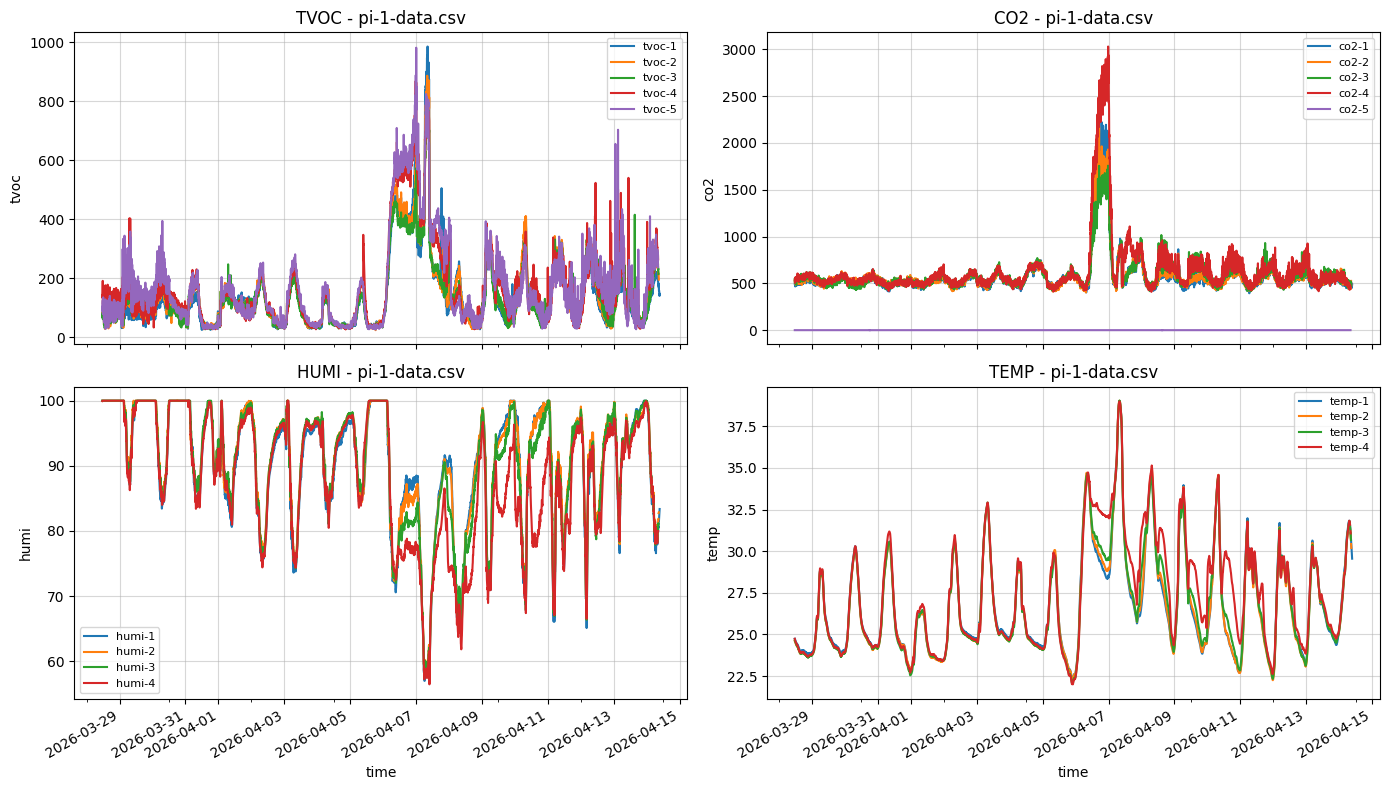

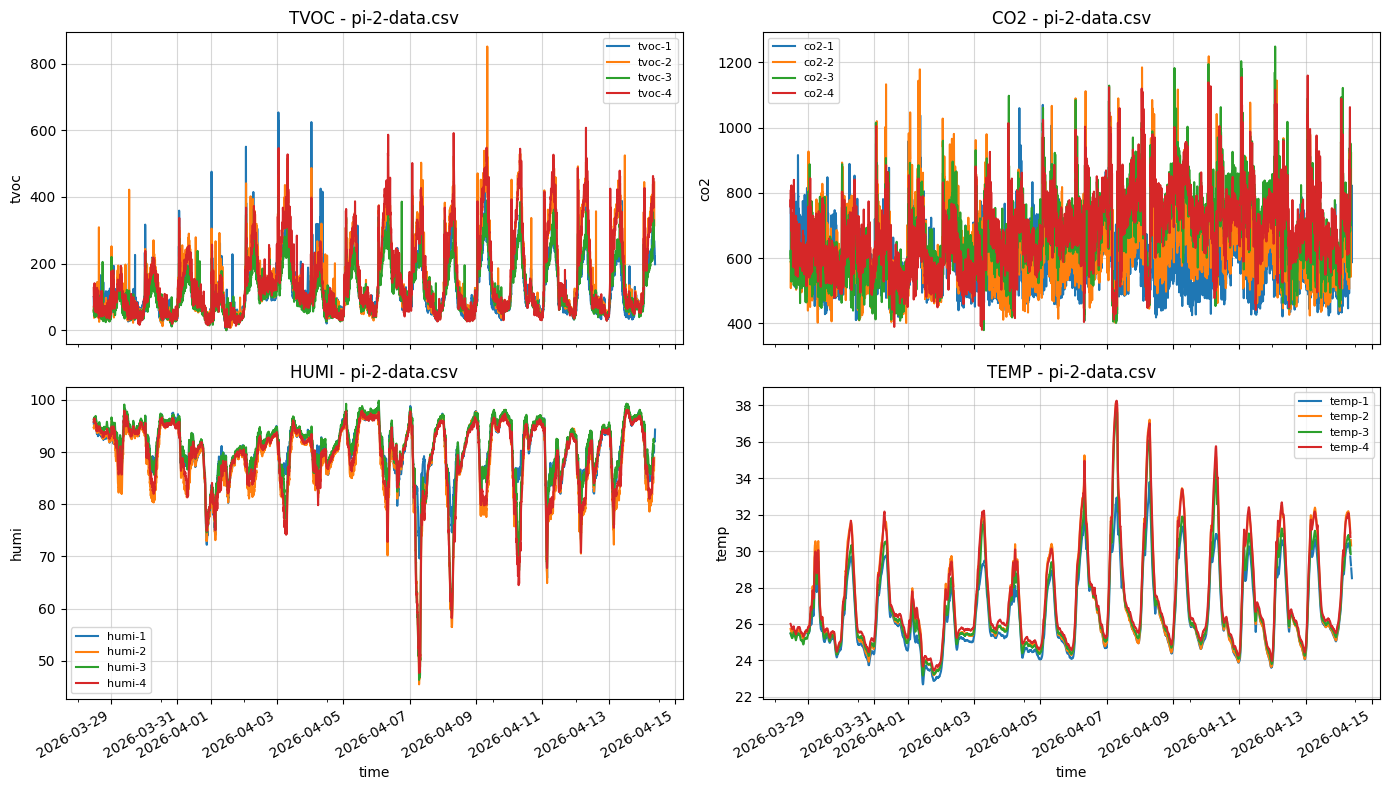

In [177]:
import matplotlib.pyplot as plt
import pandas as pd


for input_file in INPUT_FILES:
    csv_file = input_file.with_suffix(".csv")
    if not csv_file.exists():
        print(f"CSV file not found for {input_file.name}, skipping plot.")
        continue

    df = pd.read_csv(csv_file)
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", errors="coerce")
    df = df.dropna(subset=["timestamp"]).sort_values("timestamp")
    df = df.set_index("timestamp")

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    axes: np.ndarray = axes.ravel()

    for i, prefix in enumerate(["tvoc", "co2", "humi", "temp"]):
        ax: plt.Axes = axes[i]
        cols = [c for c in df.columns if c.startswith(f"{prefix}-")]

        if not cols:
            ax.set_title(f"{prefix.upper()} (no columns)")
            ax.grid(alpha=0.50)
            continue

        df[cols].plot(ax=ax)
        ax.set_title(f"{prefix.upper()} - {csv_file.name}")
        ax.set_xlabel("time")
        ax.set_ylabel(prefix)
        ax.grid(alpha=0.50)
        ax.legend(loc="best", fontsize=8)

    fig.tight_layout()
    plt.show()

## 2. Clean, Resample, and Aggregate 5-Min Data


In [ ]:
import pandas as pd
import numpy as np

GAP_MAX = 12  # <= 60 minutes

TRIM_PROPORTION = 0.3
MIN_SENSORS_PER_FAMILY = 3

FAMILY_PREFIXES = ("tvoc", "co2", "humi", "temp")


def trimmed_mean_row(values, proportion_to_cut=TRIM_PROPORTION):
    """Compute a trimmed mean of an array-like, trimming `proportion_to_cut` from each tail."""
    arr = np.asarray([v for v in values if pd.notna(v)], dtype=float)
    n = len(arr)
    if n == 0:
        return np.nan
    k = int(n * proportion_to_cut)
    if k == 0:
        return float(arr.mean())
    if n - 2 * k <= 0:
        return np.nan
    sorted_arr = np.sort(arr)
    trimmed = sorted_arr[k : n - k]
    return float(trimmed.mean())


def apply_selective_gap_fill(series: pd.Series) -> tuple[pd.Series, pd.Series]:
    """Short gaps: ffill, medium gaps: linear interpolate, long gaps: keep missing."""
    s = pd.to_numeric(series, errors="coerce").copy()

    missing = s.isna()
    group_id = missing.ne(missing.shift(fill_value=False)).cumsum()
    run_len = missing.groupby(group_id).transform("sum")

    fillable_gap = missing & (run_len <= GAP_MAX)
    long_gap = missing & (run_len > GAP_MAX)

    s_interp = s.interpolate(method="linear", limit=GAP_MAX, limit_direction="both")

    out = s.copy()
    out.loc[fillable_gap] = s_interp.loc[fillable_gap]
    return out, long_gap


def clean_align_5min(df_raw: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, int]]:
    df = df_raw.copy()

    # 1. Parse time, sort, dedupe (keep last) by timestamp
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["timestamp"]).copy()
    df["time"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.drop(columns=["timestamp"]).set_index("time").sort_index()

    before_dupes = len(df)
    df = df[~df.index.duplicated(keep="last")]
    removed_dupes = before_dupes - len(df)

    # 2. Discover sensor columns by prefix dynamically
    sensor_cols = []
    for c in df.columns:
        if "-" not in c:
            continue
        prefix, suffix = c.split("-", 1)
        if prefix in FAMILY_PREFIXES and suffix.isdigit():
            sensor_cols.append(c)

    # 3. Glitch marking
    hampel_window = 25
    sigma_multiplier = 3.0

    delta_counts: dict[str, int] = {}
    for col in sensor_cols:
        s: pd.Series = pd.to_numeric(df[col], errors="coerce")

        rolling_median = s.rolling(
            window=hampel_window, center=True, min_periods=1
        ).median()

        abs_dev = (s - rolling_median).abs()
        rolling_mad = abs_dev.rolling(
            window=hampel_window, center=True, min_periods=1
        ).median()

        threshold = sigma_multiplier * 1.4826 * rolling_mad
        # Prevent zero MAD (flat sensor periods) from causing all non-constant points to be marked as glitches
        non_zero_mads = rolling_mad[rolling_mad > 0]

        if not non_zero_mads.empty:
            base_noise_floor = sigma_multiplier * 1.4826 * non_zero_mads.median()
        else:
            # Ultimate fallback, probably will never reach
            base_noise_floor = 1.0

        threshold = threshold.clip(lower=base_noise_floor)

        glitch_mask = abs_dev > threshold
        delta_counts[col] = int(glitch_mask.sum())
        df.loc[glitch_mask, col] = np.nan

    # 4. Resample sensor channels first (median per 5-min bucket)
    sensor_5m = df[sensor_cols].resample("5min").median(numeric_only=True)

    # 5. Count valid sensors per family before aggregation, then gate the aggregate
    final_df = pd.DataFrame(index=sensor_5m.index)
    family_sensor_counts: dict[str, pd.Series] = {}
    for prefix in FAMILY_PREFIXES:
        family_cols = [c for c in sensor_5m.columns if c.startswith(f"{prefix}-")]
        if family_cols:
            family_sensor_counts[prefix] = sensor_5m[family_cols].notna().sum(axis=1)
            final_df[prefix] = sensor_5m[family_cols].apply(
                lambda row: trimmed_mean_row(
                    row.values, proportion_to_cut=TRIM_PROPORTION
                ),
                axis=1,
            )
            final_df.loc[
                family_sensor_counts[prefix] < MIN_SENSORS_PER_FAMILY, prefix
            ] = np.nan
        else:
            family_sensor_counts[prefix] = pd.Series(
                0, index=sensor_5m.index, dtype=int
            )
            final_df[prefix] = np.nan

    # 6. Count working locations (any family available at that location)
    location_ids = sorted(
        {
            int(c.split("-", 1)[1])
            for c in sensor_5m.columns
            if "-" in c and c.split("-", 1)[1].isdigit()
        }
    )

    location_active_flags = []
    for location_id in location_ids:
        location_cols = [f"{prefix}-{location_id}" for prefix in FAMILY_PREFIXES]
        present_cols = [c for c in location_cols if c in sensor_5m.columns]
        if present_cols:
            location_active_flags.append(sensor_5m[present_cols].notna().any(axis=1))

    if location_active_flags:
        final_df["valid_sensor_count"] = (
            pd.concat(location_active_flags, axis=1).sum(axis=1).astype(int)
        )
    else:
        final_df["valid_sensor_count"] = pd.Series(0, index=final_df.index, dtype=int)

    # 7. Fill short/medium gaps, drop rows with any long gap
    long_gap_any = pd.Series(False, index=final_df.index)
    for col in ["tvoc", "co2", "humi", "temp"]:
        final_df[col], long_gap_mask = apply_selective_gap_fill(final_df[col])
        long_gap_any |= long_gap_mask

    rows_before_drop = len(final_df)
    final_df = final_df.loc[~long_gap_any].copy()
    rows_dropped_long_gaps = rows_before_drop - len(final_df)

    final_df = final_df.reset_index()

    report = {
        "rows_in": int(len(df_raw)),
        "rows_5min": int(len(final_df)),
        "rows_with_le_2_sensors_working": int(
            (final_df["valid_sensor_count"] <= 2).sum()
        ),
        "dupe_timestamps_removed": int(removed_dupes),
        "delta_glitches_marked_total": int(sum(delta_counts.values())),
        "rows_dropped_long_gaps": int(rows_dropped_long_gaps),
        "missing_after_fill_total": int(
            final_df[["tvoc", "co2", "humi", "temp"]].isna().sum().sum()
        ),
    }
    return final_df, report


cleaned_reports: list[dict[str, int | str]] = []
cleaned_frames: dict[str, pd.DataFrame] = {}

for input_name in ["pi-1-data.csv", "pi-2-data.csv"]:
    input_path = BASE_DIR / input_name
    if not input_path.exists():
        print(f"Skipping missing CSV: {input_name}")
        continue

    raw_df = pd.read_csv(input_path)
    cleaned_df, stats = clean_align_5min(raw_df)
    cleaned_frames[input_name] = cleaned_df

    out_name = input_name.replace(".csv", "-clean-5min.csv")
    cleaned_df.to_csv(BASE_DIR / out_name, index=False)

    cleaned_reports.append({"input": input_name, "output": out_name, **stats})

clean_report_df = pd.DataFrame(cleaned_reports)
clean_report_df

,input,output,rows_in,rows_5min,rows_with_le_2_sensors_working,dupe_timestamps_removed,delta_glitches_marked_total,rows_dropped_long_gaps,missing_after_fill_total
0,pi-1-data.csv,pi-1-data-clean-5min.csv,4861,4873,24,0,1633,0,0


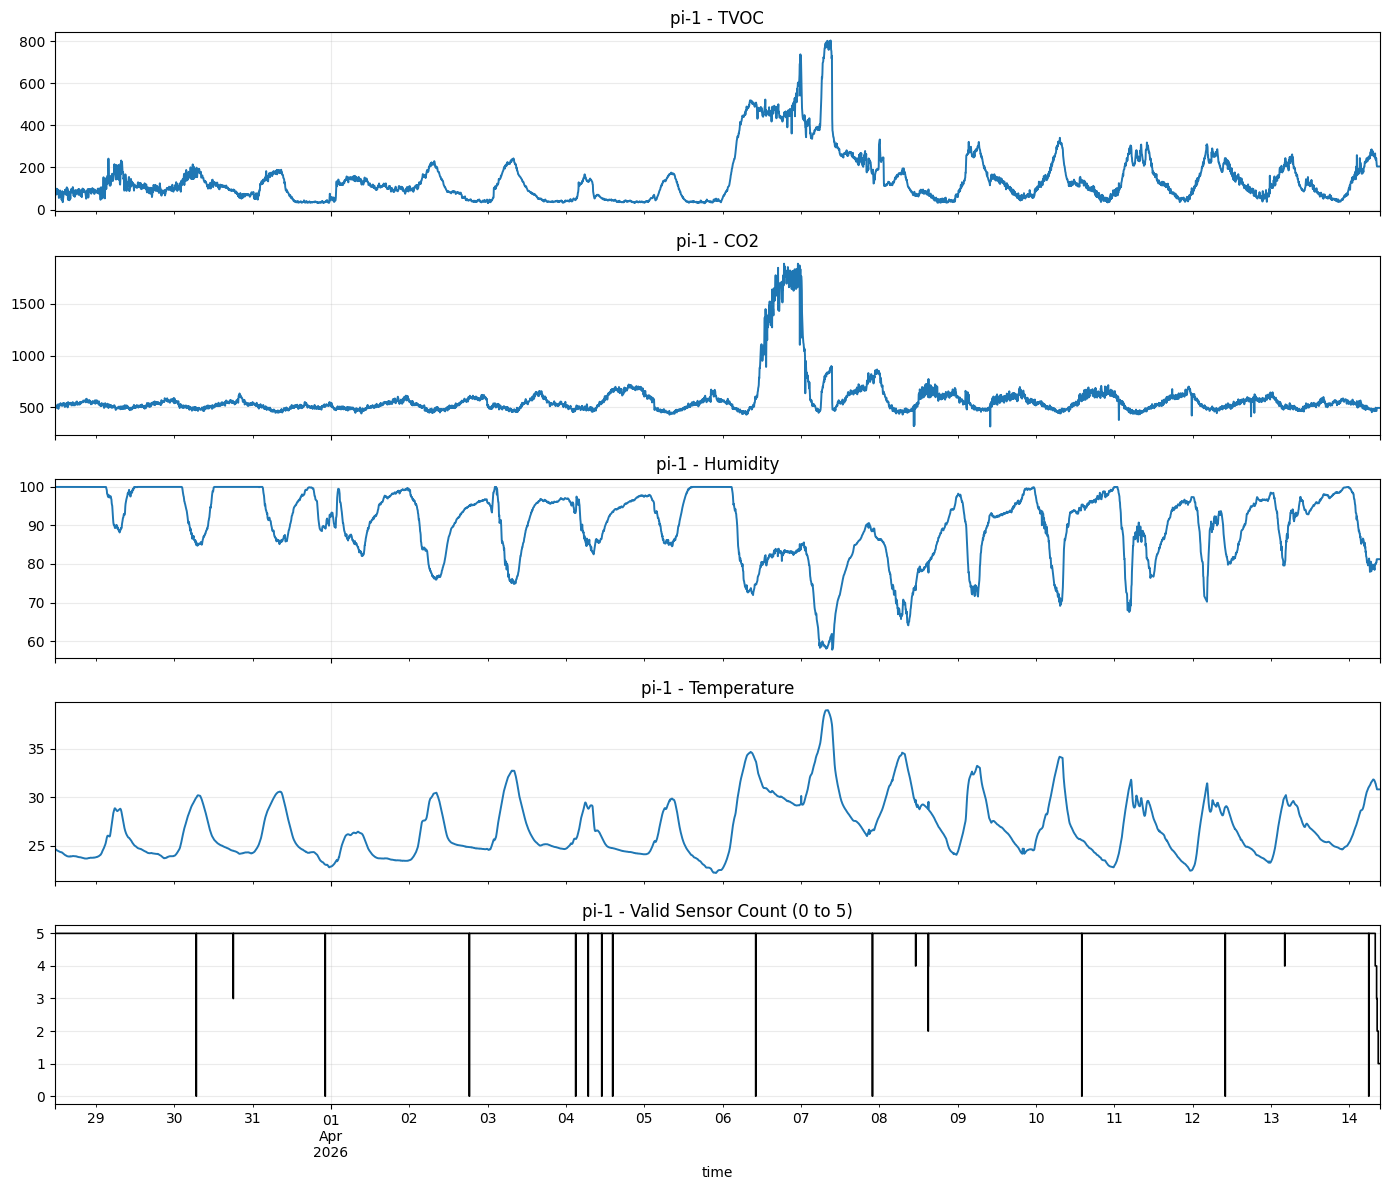

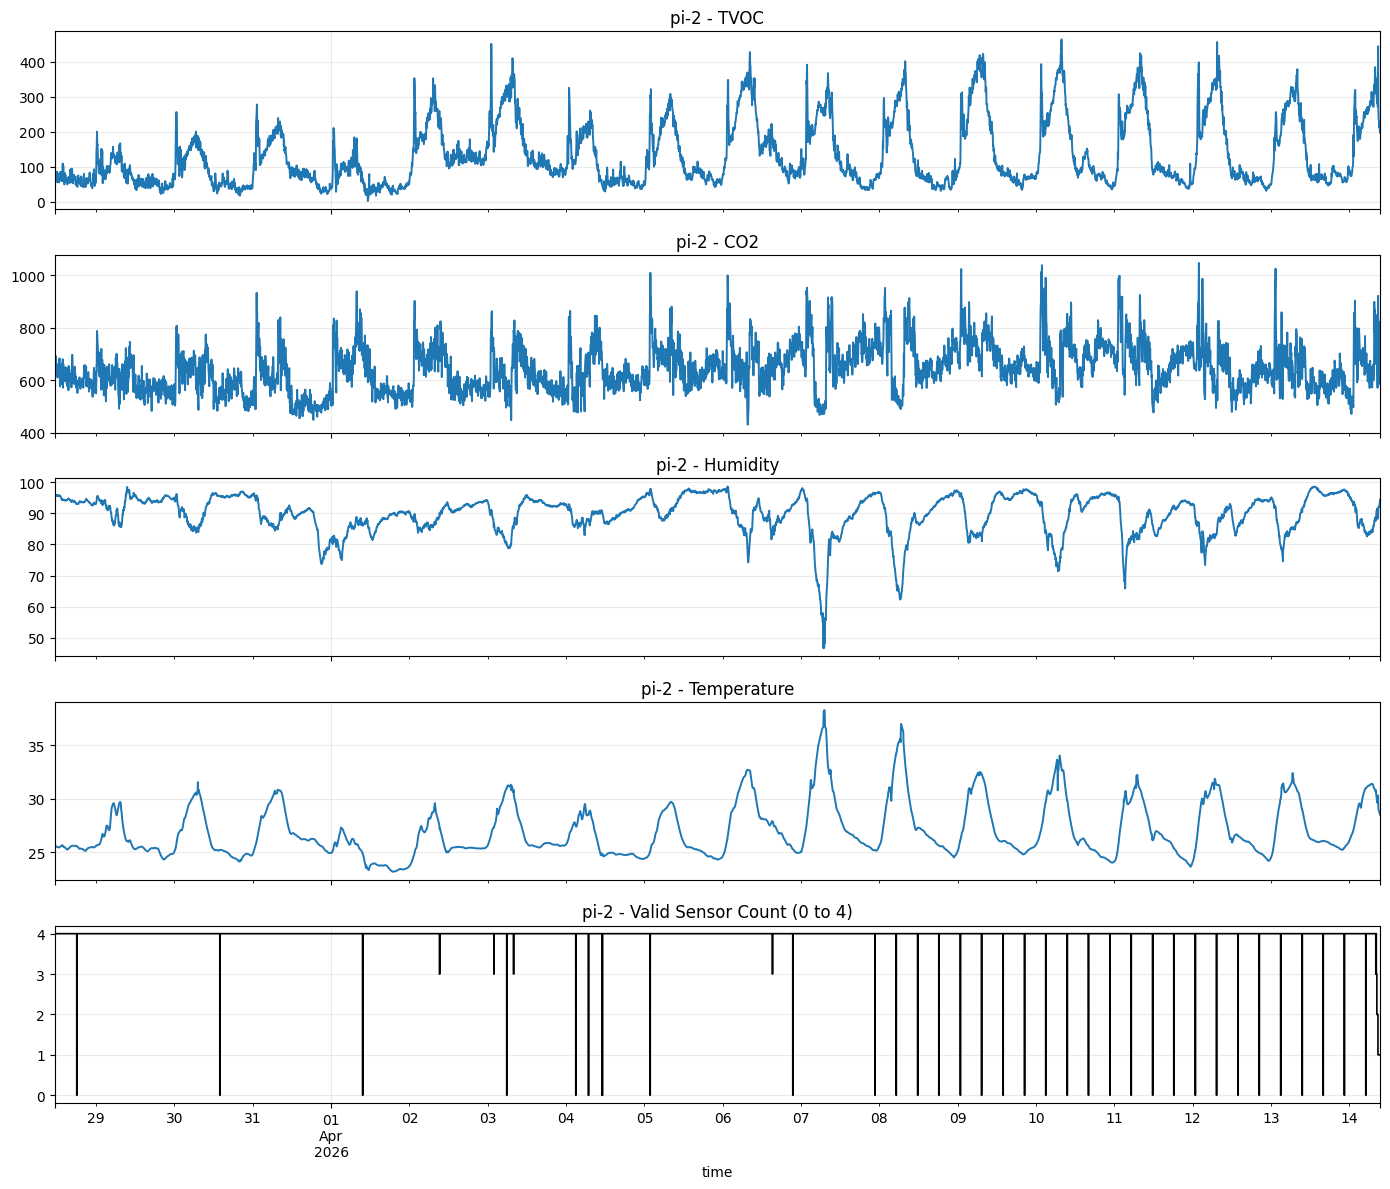

In [179]:
import matplotlib.pyplot as plt


def plot_cleaned_dataset(df: pd.DataFrame, title_prefix: str) -> None:
    plot_df = df.copy()
    plot_df["time"] = pd.to_datetime(plot_df["time"], utc=True)
    plot_df = plot_df.set_index("time")

    _, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

    for ax, col, label in [
        (axes[0], "tvoc", "TVOC"),
        (axes[1], "co2", "CO2"),
        (axes[2], "humi", "Humidity"),
        (axes[3], "temp", "Temperature"),
    ]:
        if col in plot_df.columns:
            plot_df[col].plot(ax=ax, linewidth=1.4)
        ax.set_title(f"{title_prefix} - {label}")
        ax.grid(alpha=0.25)

    max_valid = (
        int(plot_df["valid_sensor_count"].max())
        if "valid_sensor_count" in plot_df.columns
        else 0
    )
    if "valid_sensor_count" in plot_df.columns:
        plot_df["valid_sensor_count"].plot(
            ax=axes[4], linewidth=1.2, color="black", drawstyle="steps-mid"
        )
    axes[4].set_title(f"{title_prefix} - Valid Sensor Count (0 to {max_valid})")
    axes[4].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


for input_name in ["pi-1-data-clean-5min.csv", "pi-2-data-clean-5min.csv"]:
    prefix = input_name.replace("-data-clean-5min.csv", "").replace(".csv", "")
    cleaned_df = pd.read_csv(input_name)
    plot_cleaned_dataset(cleaned_df, title_prefix=prefix)

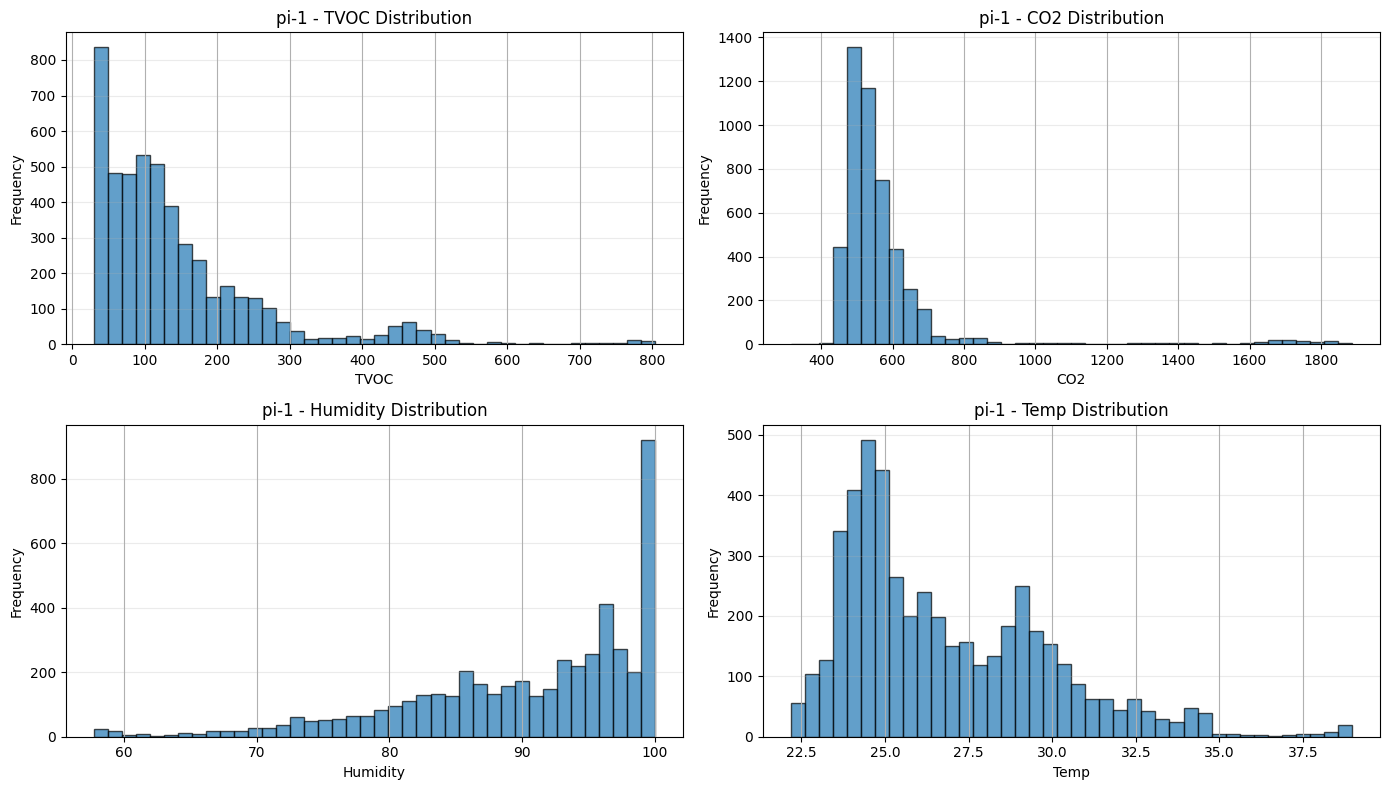

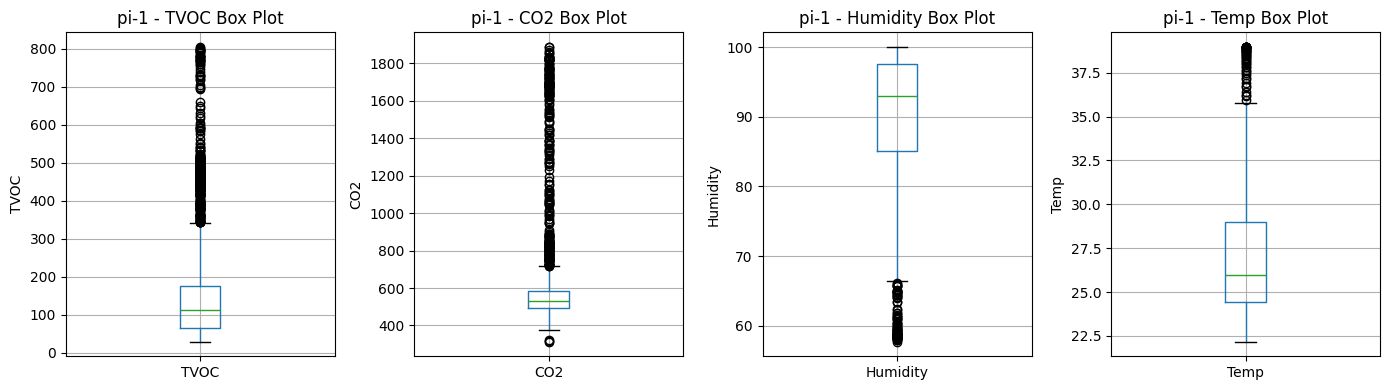

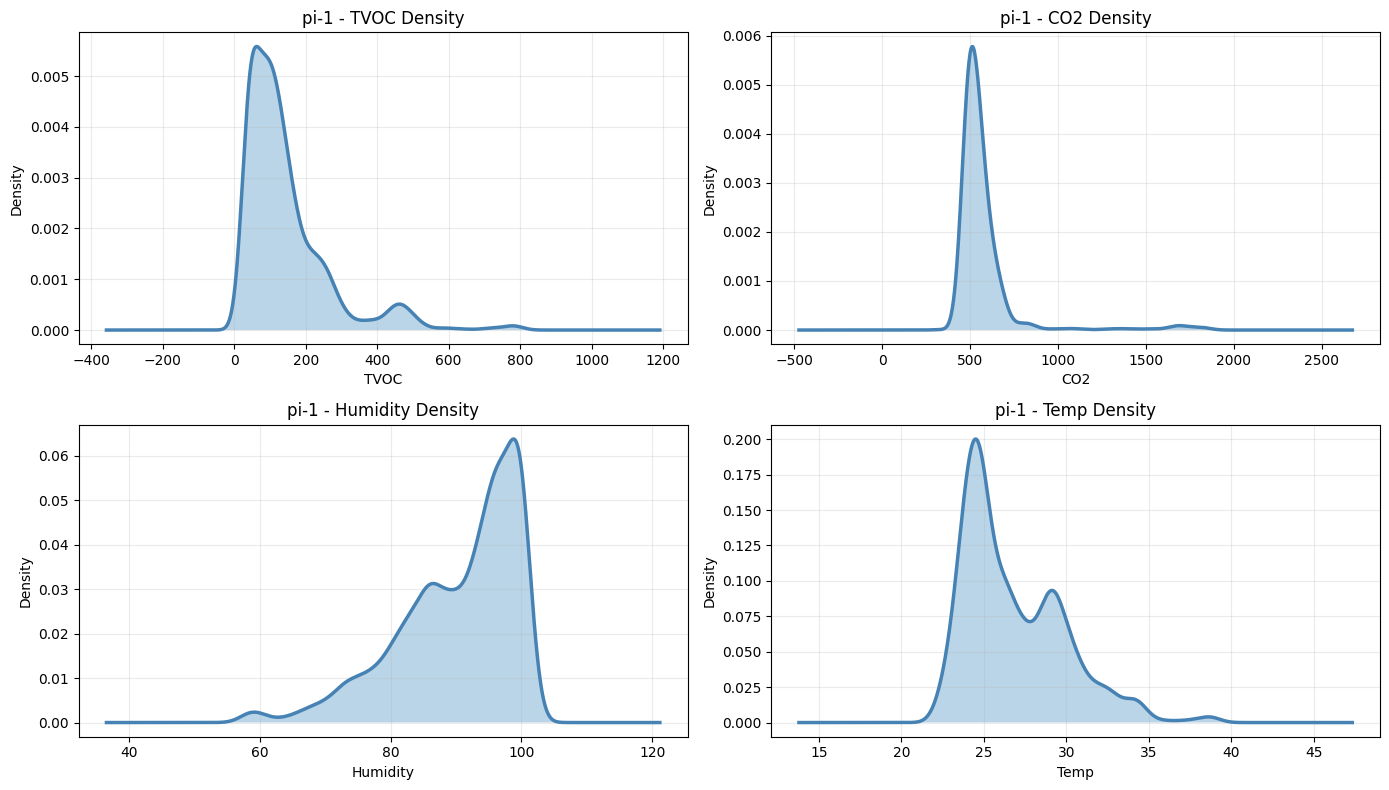

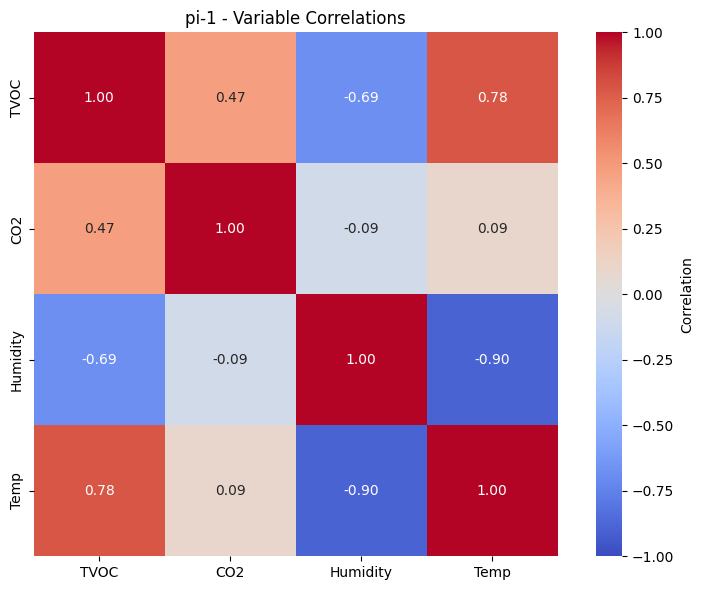


pi-1 - Summary Statistics:
           TVOC       CO2  Humidity      Temp
count  4873.000  4873.000  4873.000  4873.000
mean    144.860   576.915    90.345    26.822
std     120.632   197.518     9.014     3.058
min      29.667   314.000    57.743    22.180
25%      65.000   494.333    85.100    24.435
50%     111.333   530.667    93.010    25.965
75%     176.000   584.000    97.575    28.990
max     804.000  1887.000   100.000    38.960

pi-1 - Percentiles (25%, 50%, 75%):
         TVOC      CO2  Humidity    Temp
0.25   65.000  494.333    85.100  24.435
0.50  111.333  530.667    93.010  25.965
0.75  176.000  584.000    97.575  28.990

pi-1 - Skewness & Kurtosis:
  Skewness: {'TVOC': 2.213, 'CO2': 4.608, 'Humidity': -1.059, 'Temp': 1.017}
  Kurtosis: {'TVOC': 6.177, 'CO2': 23.0, 'Humidity': 0.75, 'Temp': 0.834}


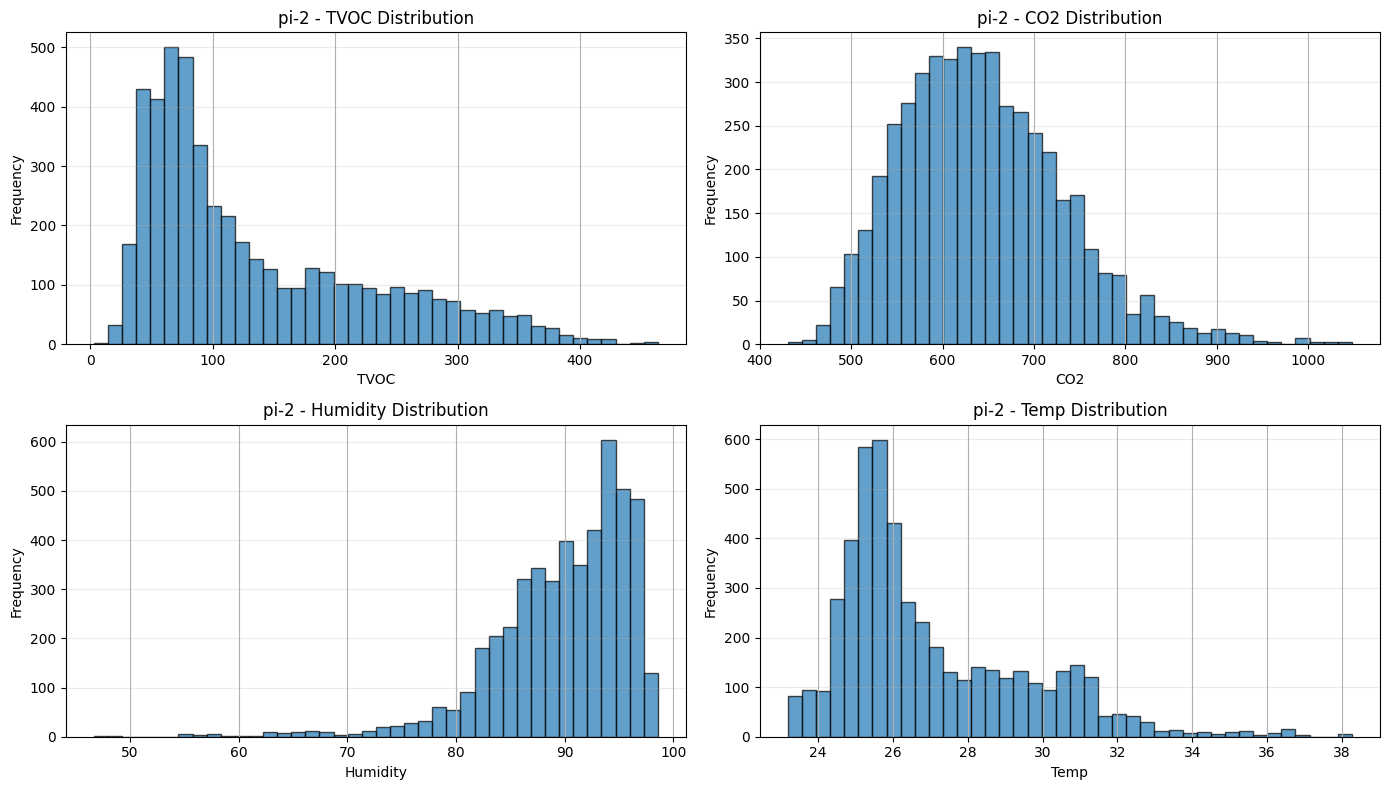

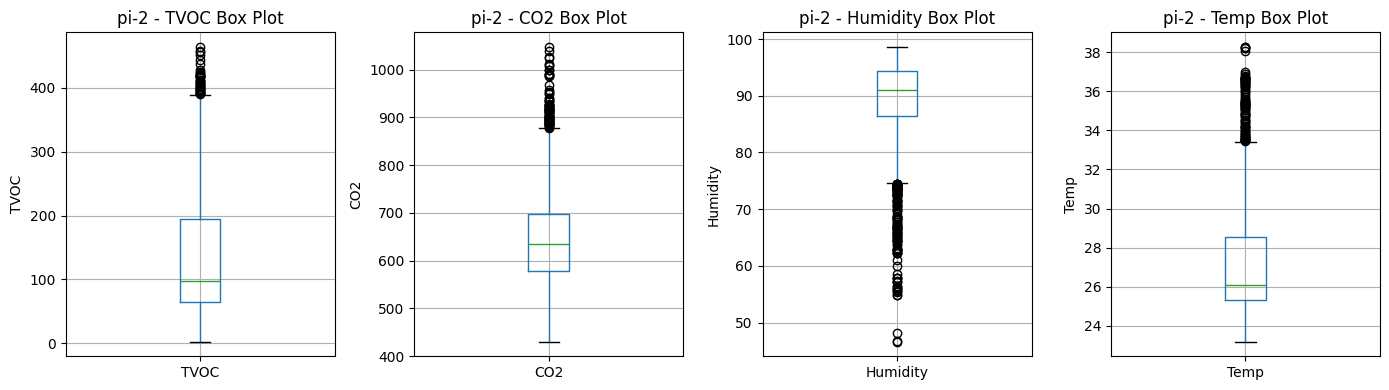

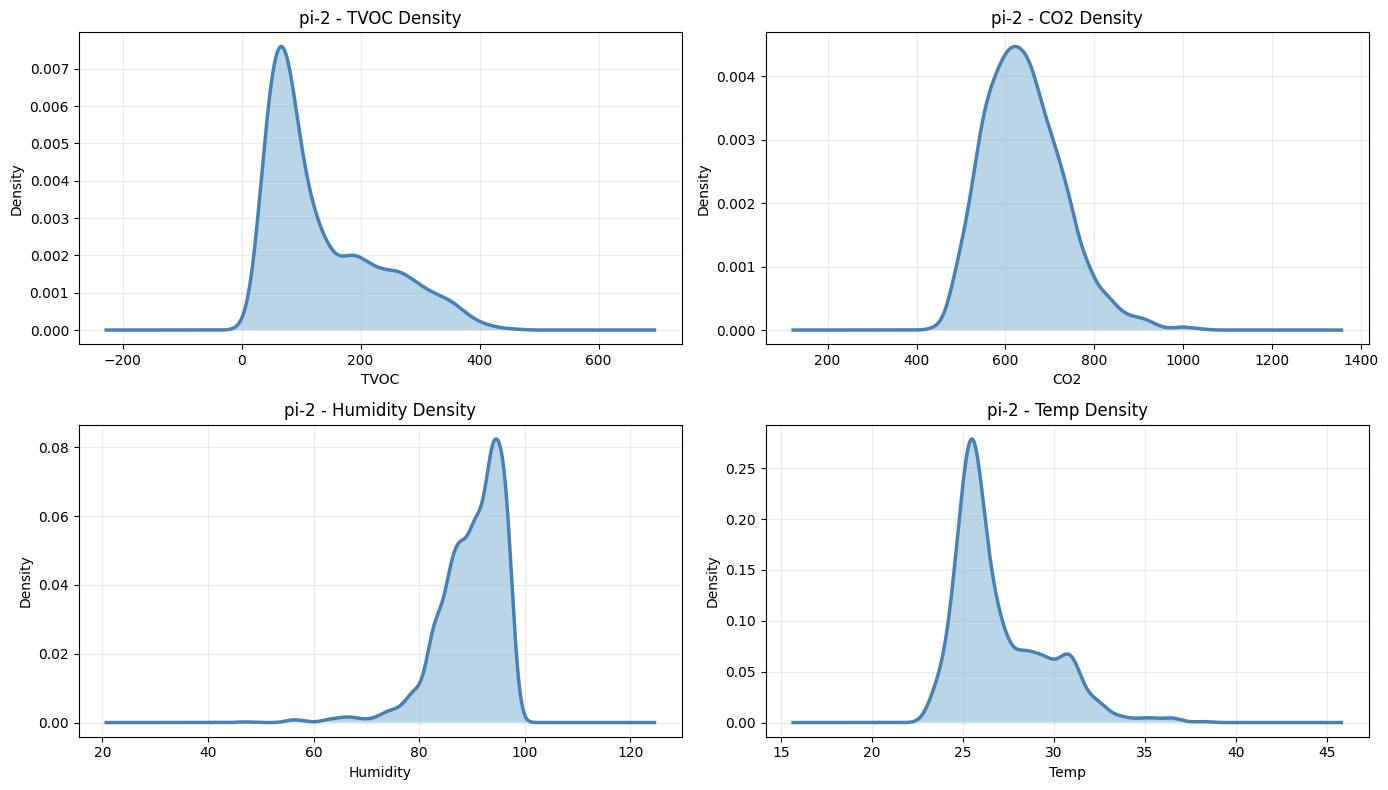

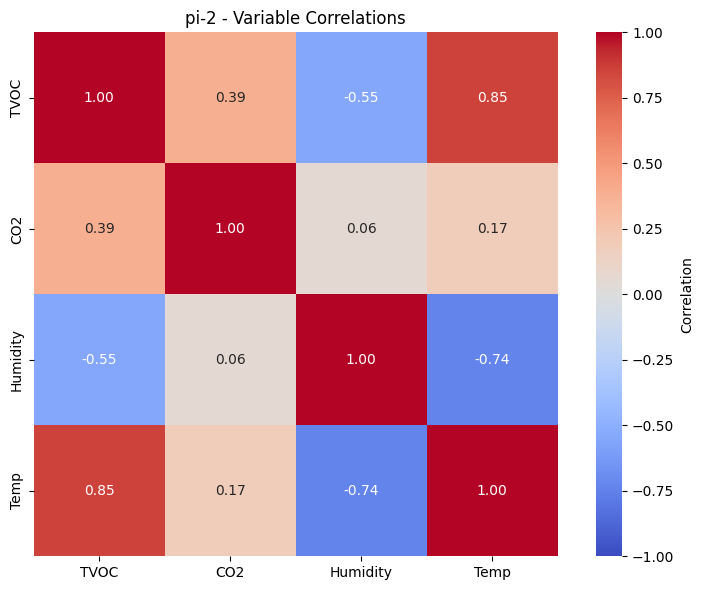


pi-2 - Summary Statistics:
           TVOC       CO2  Humidity      Temp
count  4874.000  4874.000  4874.000  4874.000
mean    135.548   643.309    89.811    27.020
std      93.301    89.406     6.284     2.513
min       2.750   430.750    46.670    23.195
25%      64.250   577.750    86.483    25.296
50%      97.750   634.500    90.980    26.100
75%     194.188   698.188    94.441    28.553
max     463.667  1047.500    98.588    38.260

pi-2 - Percentiles (25%, 50%, 75%):
         TVOC      CO2  Humidity    Temp
0.25   64.250  577.750    86.483  25.296
0.50   97.750  634.500    90.980  26.100
0.75  194.188  698.188    94.441  28.553

pi-2 - Skewness & Kurtosis:
  Skewness: {'TVOC': 1.022, 'CO2': 0.669, 'Humidity': -1.666, 'Temp': 1.168}
  Kurtosis: {'TVOC': 0.05, 'CO2': 0.695, 'Humidity': 4.991, 'Temp': 1.129}


In [180]:
import seaborn as sns


def plot_statistical_summary(df: pd.DataFrame, title_prefix: str) -> None:
    """Plot comprehensive statistical summaries: histograms, box plots, distributions, correlation."""
    numeric_df = df[["tvoc", "co2", "humi", "temp"]].copy()
    numeric_df.columns = ["TVOC", "CO2", "Humidity", "Temp"]

    # 1. Histograms
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for ax, col in zip(axes.ravel(), numeric_df.columns):
        numeric_df[col].hist(bins=40, ax=ax, edgecolor="black", alpha=0.7)
        ax.set_title(f"{title_prefix} - {col} Distribution")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")
        ax.grid(alpha=0.25, axis="y")
    fig.tight_layout()
    plt.show()

    # 2. Box plots
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    for ax, col in zip(axes, numeric_df.columns):
        numeric_df.boxplot(column=col, ax=ax)
        ax.set_title(f"{title_prefix} - {col} Box Plot")
        ax.set_ylabel(col)
    fig.tight_layout()
    plt.show()

    # 3. Density (KDE) plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for ax, col in zip(axes.ravel(), numeric_df.columns):
        numeric_df[col].dropna().plot.density(ax=ax, linewidth=2.5, color="steelblue")
        if len(ax.lines) > 0:
            x_data = ax.lines[0].get_xdata()
            y_data = ax.lines[0].get_ydata()
            ax.fill_between(x_data, y_data, alpha=0.3)
        ax.set_title(f"{title_prefix} - {col} Density")
        ax.set_xlabel(col)
        ax.set_ylabel("Density")
        ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

    # 4. Correlation heatmap
    corr_matrix = numeric_df.corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        ax=ax,
        cbar_kws={"label": "Correlation"},
        vmin=-1,
        vmax=1,
    )
    ax.set_title(f"{title_prefix} - Variable Correlations")
    plt.tight_layout()
    plt.show()

    # 5. Summary statistics table
    print(f"\n{title_prefix} - Summary Statistics:")
    print(numeric_df.describe().round(3))
    print(f"\n{title_prefix} - Percentiles (25%, 50%, 75%):")
    print(numeric_df.quantile([0.25, 0.5, 0.75]).round(3))
    print(f"\n{title_prefix} - Skewness & Kurtosis:")
    print(f"  Skewness: {numeric_df.skew().round(3).to_dict()}")
    print(f"  Kurtosis: {numeric_df.kurtosis().round(3).to_dict()}")


for input_name in ["pi-1-data-clean-5min.csv", "pi-2-data-clean-5min.csv"]:
    prefix = input_name.replace("-data-clean-5min.csv", "").replace(".csv", "")
    cleaned_df = pd.read_csv(input_name)
    plot_statistical_summary(cleaned_df, title_prefix=prefix)

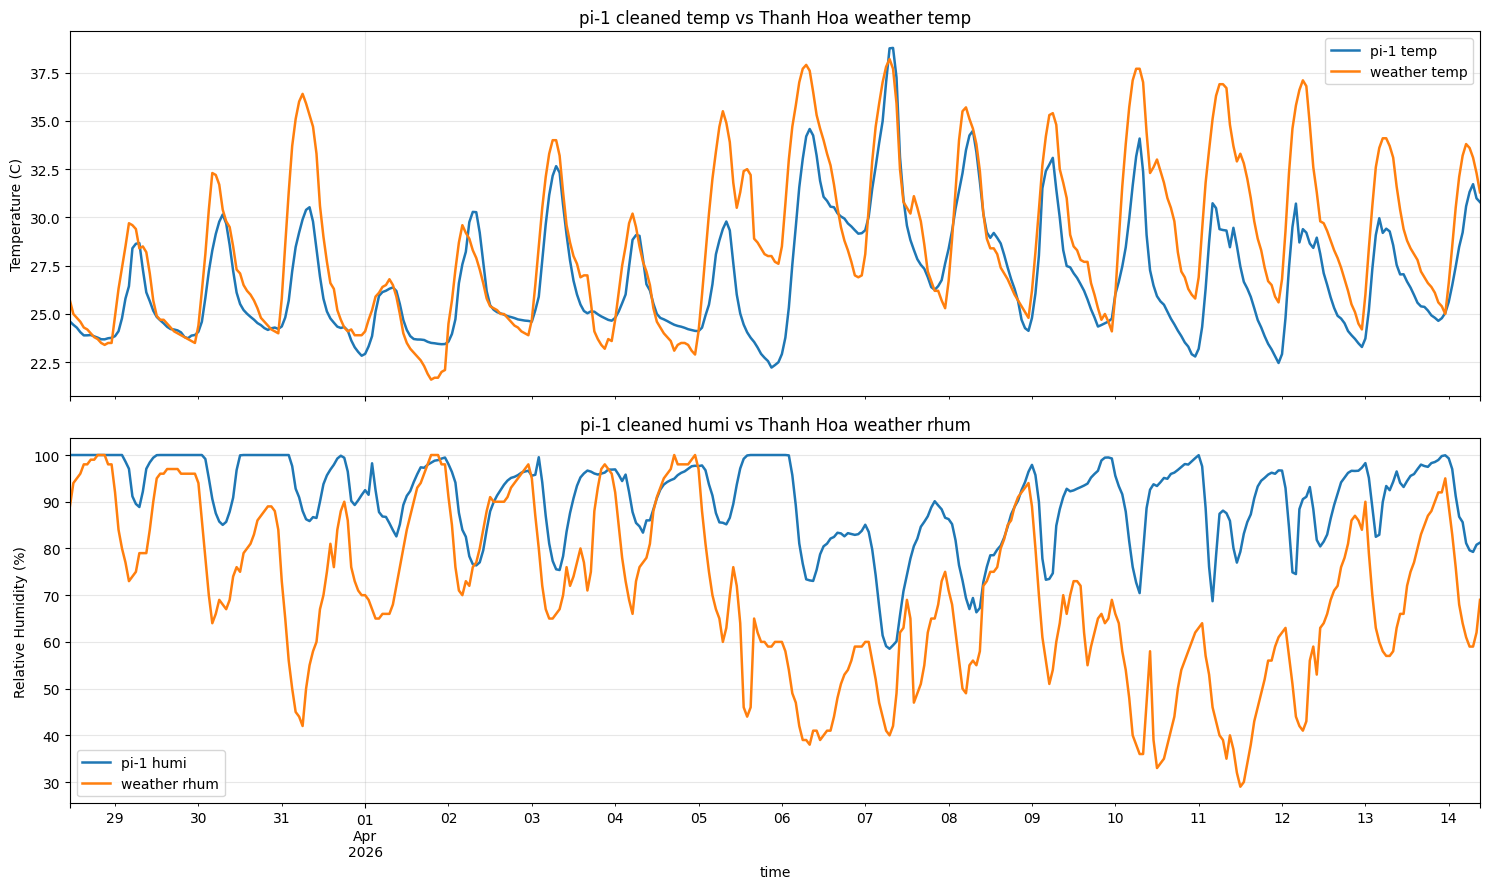

Overlap summary:
               temp  weather_temp   humi  weather_rhum
temp          1.000         0.813 -0.898        -0.582
weather_temp  0.813         1.000 -0.669        -0.832
humi         -0.898        -0.669  1.000         0.545
weather_rhum -0.582        -0.832  0.545         1.000


In [181]:
import matplotlib.pyplot as plt
import pandas as pd

weather_path = BASE_DIR / "thanhhoa_weather.csv"
pi1_clean_path = BASE_DIR / "pi-1-data-clean-5min.csv"

weather_df = pd.read_csv(weather_path)
weather_df["time"] = pd.to_datetime(weather_df["time"], errors="coerce")
weather_df = weather_df.dropna(subset=["time"]).sort_values("time").set_index("time")
weather_df.index = weather_df.index.tz_localize("UTC")
weather_df = weather_df.rename(columns={"temp": "weather_temp", "rhum": "weather_rhum"})

pi1_df = pd.read_csv(pi1_clean_path)
pi1_df["time"] = pd.to_datetime(pi1_df["time"], utc=True, errors="coerce")
pi1_df = pi1_df.dropna(subset=["time"]).sort_values("time").set_index("time")
pi1_df.index = pi1_df.index.tz_convert("UTC")

# Match the weather data resolution so the lines are comparable in UTC.
pi1_hourly = pi1_df[["temp", "humi"]].resample("1h").mean()
weather_df = weather_df.resample("1h").mean()

comparison_df = pi1_hourly.join(weather_df, how="inner")
comparison_df = comparison_df.dropna(
    subset=["temp", "humi", "weather_temp", "weather_rhum"], how="all"
)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

comparison_df[["temp", "weather_temp"]].plot(ax=axes[0], linewidth=1.8)
axes[0].set_title("pi-1 cleaned temp vs Thanh Hoa weather temp")
axes[0].set_ylabel("Temperature (C)")
axes[0].grid(alpha=0.3)
axes[0].legend(["pi-1 temp", "weather temp"], loc="best")

comparison_df[["humi", "weather_rhum"]].plot(ax=axes[1], linewidth=1.8)
axes[1].set_title("pi-1 cleaned humi vs Thanh Hoa weather rhum")
axes[1].set_ylabel("Relative Humidity (%)")
axes[1].set_xlabel("time")
axes[1].grid(alpha=0.3)
axes[1].legend(["pi-1 humi", "weather rhum"], loc="best")

plt.tight_layout()
plt.show()

print("Overlap summary:")
print(comparison_df[["temp", "weather_temp", "humi", "weather_rhum"]].corr().round(3))

In [ ]:
import pandas as pd

weather_path = BASE_DIR / "thanhhoa_weather.csv"
pi1_clean_path = BASE_DIR / "pi-1-data-clean-5min.csv"
out_path = BASE_DIR / "thanhhoa_weather-5min.csv"

weather_df = pd.read_csv(weather_path)
weather_df["time"] = pd.to_datetime(weather_df["time"], errors="coerce")
weather_df = weather_df.dropna(subset=["time"]).sort_values("time").set_index("time")
weather_df.index = weather_df.index.tz_localize("UTC")
weather_df = weather_df.rename(columns={"temp": "weather_temp", "rhum": "weather_rhum"})

pi1_df = pd.read_csv(pi1_clean_path)
pi1_df["time"] = pd.to_datetime(pi1_df["time"], utc=True, errors="coerce")
pi1_df = pi1_df.dropna(subset=["time"]).sort_values("time").set_index("time")
pi1_df.index = pi1_df.index.tz_convert("UTC")

target_index = pi1_df.index
weather_5min = (
    weather_df[["weather_temp", "weather_rhum"]]
    .reindex(weather_df.index.union(target_index))
    .sort_index()
    .interpolate(method="time")
    .ffill()
    .bfill()
    .reindex(target_index)
)

weather_5min = weather_5min.reset_index().rename(columns={"index": "time"})
weather_5min.to_csv(out_path, index=False)

print(f"Saved interpolated weather dataset to {out_path.name}")
print(weather_5min.head())

Saved synced weather dataset to thanhhoa_weather-5min.csv
                       time  weather_temp  weather_rhum
0 2026-03-28 11:25:00+00:00     25.408333     91.083333
1 2026-03-28 11:30:00+00:00     25.350000     91.500000
2 2026-03-28 11:35:00+00:00     25.291667     91.916667
3 2026-03-28 11:40:00+00:00     25.233333     92.333333
4 2026-03-28 11:45:00+00:00     25.175000     92.750000


In [182]:
# Calculate rolling standard deviation on numeric columns only.
for input_name in ["pi-1-data-clean-5min.csv", "pi-2-data-clean-5min.csv"]:
    print(f"Rolling std for {input_name}:")
    cleaned_df = pd.read_csv(input_name)
    window = 6  # 30 minutes at 5-minute intervals
    numeric_cleaned_df = cleaned_df.select_dtypes(include=["number"])
    summary = pd.DataFrame(
        {
            "avg_rolling_std": numeric_cleaned_df.rolling(window=window).std().mean(),
            "mad": numeric_cleaned_df.diff().abs().mean(),
        }
    )
    print(summary)
    print(f"Describe for {input_name}:")
    print(numeric_cleaned_df.describe())

Rolling std for pi-1-data-clean-5min.csv:
                    avg_rolling_std        mad
tvoc                       8.799549   8.140599
co2                       16.993630  18.301314
humi                       0.429551   0.282584
temp                       0.107414   0.058371
valid_sensor_count         0.035629   0.028325
Describe for pi-1-data-clean-5min.csv:
              tvoc          co2         humi         temp  valid_sensor_count
count  4873.000000  4873.000000  4873.000000  4873.000000         4873.000000
mean    144.860250   576.915384    90.344668    26.822057            4.975990
std     120.631607   197.517899     9.013516     3.058326            0.311977
min      29.666667   314.000000    57.743333    22.180000            0.000000
25%      65.000000   494.333333    85.100000    24.435000            5.000000
50%     111.333333   530.666667    93.010000    25.965000            5.000000
75%     176.000000   584.000000    97.575000    28.990000            5.000000
max     804.0

In [183]:
import pandas as pd


def one_step_abs_diff(x: pd.Series) -> pd.Series:
    x = pd.to_numeric(x, errors="coerce").dropna()
    return x.diff().abs().dropna()


def positive_excess(x: pd.Series, target: float) -> pd.Series:
    x = pd.to_numeric(x, errors="coerce").dropna()
    return (x - target).clip(lower=0.0)


# Build one combined calibration frame if you have multiple cleaned datasets.
all_frames = []
for input_name in ["pi-1-data-clean-5min.csv", "pi-2-data-clean-5min.csv"]:
    df = pd.read_csv(input_name)
    tmp = df.copy()
    tmp["source"] = input_name
    all_frames.append(tmp)
cal_df = pd.concat(all_frames, ignore_index=True)

# Progress scales: typical one-step changes.
tvoc_progress_norm = one_step_abs_diff(cal_df["tvoc"]).median()
co2_progress_norm = one_step_abs_diff(cal_df["co2"]).median()

# Excess scales: typical positive violations above target.
tvoc_excess_norm = positive_excess(cal_df["tvoc"], 50.0).quantile(0.75)
co2_excess_norm = positive_excess(cal_df["co2"], 400.0).quantile(0.75)
rh_excess_norm = positive_excess(cal_df["humi"], 90.0).quantile(0.75)

# Cold excess needs temperature-first logic.
cold_excess_norm = positive_excess(18.0 - cal_df["temp"], 0.0).quantile(0.75)
print(pd.to_numeric(cal_df["temp"], errors="coerce").dropna().describe())

# THI excess norm from the derived THI series.
thi = (
    (0.8 * cal_df["temp"]) + ((cal_df["humi"] / 100.0) * (cal_df["temp"] - 14.4)) + 46.4
)
thi_excess_norm = positive_excess(thi, 73.0).quantile(0.75)

fallbacks = {
    "TVOC_PROGRESS_NORM": tvoc_progress_norm,
    "TVOC_EXCESS_NORM": tvoc_excess_norm,
    "CO2_PROGRESS_NORM": co2_progress_norm,
    "CO2_EXCESS_NORM": co2_excess_norm,
    "THI_EXCESS_NORM": thi_excess_norm,
    "RH_EXCESS_NORM": rh_excess_norm,
    "COLD_EXCESS_NORM": cold_excess_norm,
}

for k, v in fallbacks.items():
    print(f"{k:>18s} = {v:.4f}")

count    9747.000000
mean       26.920993
std         2.800409
min        22.180000
25%        24.850000
50%        26.055000
75%        28.798056
max        38.960000
Name: temp, dtype: float64
TVOC_PROGRESS_NORM = 5.7500
  TVOC_EXCESS_NORM = 135.1250
 CO2_PROGRESS_NORM = 16.6667
   CO2_EXCESS_NORM = 258.2917
   THI_EXCESS_NORM = 8.8412
    RH_EXCESS_NORM = 5.8625
  COLD_EXCESS_NORM = 0.0000


In [184]:
# Observation normalization constants derived from cleaned sensor data.
# Uses p1/p99 to cover realistic range without sensitivity to spikes.

_obs_tvoc = pd.to_numeric(cal_df["tvoc"], errors="coerce").dropna()
_obs_co2 = pd.to_numeric(cal_df["co2"], errors="coerce").dropna()
_obs_temp = pd.to_numeric(cal_df["temp"], errors="coerce").dropna()
_obs_rh = pd.to_numeric(cal_df["humi"], errors="coerce").dropna()

TVOC_OBS_DIVISOR = float(_obs_tvoc.quantile(0.99))
CO2_OBS_DIVISOR = float(_obs_co2.quantile(0.99))
TEMP_OBS_DIVISOR = float(_obs_temp.quantile(0.99))
RH_OBS_MIN = float(_obs_rh.quantile(0.01))
RH_OBS_SPAN = float(_obs_rh.quantile(0.99)) - RH_OBS_MIN

for name, val in [
    ("TVOC_OBS_DIVISOR", TVOC_OBS_DIVISOR),
    ("CO2_OBS_DIVISOR", CO2_OBS_DIVISOR),
    ("TEMP_OBS_DIVISOR", TEMP_OBS_DIVISOR),
    ("RH_OBS_MIN", RH_OBS_MIN),
    ("RH_OBS_SPAN", RH_OBS_SPAN),
]:
    print(f"{name:>18s} = {val:.4f}")

print("Post-normalization std per observation dimension:")
for name, series, divisor, shift in [
    ("tvoc", _obs_tvoc, TVOC_OBS_DIVISOR, 0.0),
    ("co2", _obs_co2, CO2_OBS_DIVISOR, 0.0),
    ("temp", _obs_temp, TEMP_OBS_DIVISOR, 0.0),
    ("rh", _obs_rh, RH_OBS_SPAN, RH_OBS_MIN),
]:
    normed = (series - shift) / divisor
    print(
        f"  {name:>6s}  std={normed.std():.3f}  min={normed.min():.3f}  max={normed.max():.3f}"
    )

  TVOC_OBS_DIVISOR = 494.6483
   CO2_OBS_DIVISOR = 1536.9867
  TEMP_OBS_DIVISOR = 35.2306
        RH_OBS_MIN = 64.3650
       RH_OBS_SPAN = 35.6350
Post-normalization std per observation dimension:
    tvoc  std=0.218  min=0.006  max=1.625
     co2  std=0.102  min=0.204  max=1.228
    temp  std=0.079  min=0.630  max=1.106
      rh  std=0.218  min=-0.497  max=1.000
